# Tester_branch에서 성능 확인 진행

In [2]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

' 데이터 코드를 작성해주세요 '

# DT 모델링 성능

In [11]:
''' 코드를 작성해주세요 '''
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report
# 와인 데이터 로드
wine = load_wine()

# DataFrame으로 변환
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# feature와 target 분리
feature = df.drop(columns='target')
target = df['target']

# train/test 분할
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

param_grid = {
     'criterion': ['gini', 'entropy'],
     'max_depth': [2, 3, 4, 5],
     'min_samples_split': [2, 5, 10],
     'min_samples_leaf': [1, 2, 4]
}
 

clf = DecisionTreeClassifier()

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,  # 5-fold cross validation
    scoring='accuracy',  # 평가 지표
    verbose=1,
    n_jobs=-1  # 모든 코어 사용
)

grid_search.fit(X_train, y_train)
# 예측
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

# 테스트 세트 정확도 확인
best_model = grid_search.best_estimator_
DT_pred = best_model.predict(X_test)
DT = accuracy_score(y_test, DT_pred)



Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Cross-validation Score: 0.929064039408867


<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

In [12]:
''' 코드를 작성해주세요 '''
# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

''' 해당 부분은 직접 작성 바랍니다 '''
from sklearn.datasets import load_wine
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report
# 와인 데이터 로드
wine = load_wine()

# DataFrame으로 변환
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# feature와 target 분리
feature = df.drop(columns='target')
target = df['target']

# train/test 분할
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

param_grid = {
     'max_depth': [3, 5, 7, 9, 15], 
     'learning_rate': [0.1, 0.01, 0.001],
     'n_estimators': [50, 100, 200, 300]
}


xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,  # 5-fold cross validation
    scoring='accuracy',  # 평가 지표
    verbose=1,
    n_jobs=-1  # 모든 코어 사용
)

grid_search.fit(X_train, y_train)
# 예측
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

# 테스트 세트 정확도 확인
best_model = grid_search.best_estimator_
XGB_pred = best_model.predict(X_test)
XGB =  accuracy_score(y_test, XGB_pred)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


/Users/lee-junyeol/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:41:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/lee-junyeol/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:41:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/lee-junyeol/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:41:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/lee-junyeol/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:41:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(sms

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Cross-validation Score: 0.9576354679802955


/Users/lee-junyeol/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:41:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/lee-junyeol/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:41:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/lee-junyeol/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:41:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.88      1.00      0.93        14
           2       1.00      0.62      0.77         8

    accuracy                           0.92        36
   macro avg       0.94      0.88      0.89        36
weighted avg       0.93      0.92      0.91        36

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



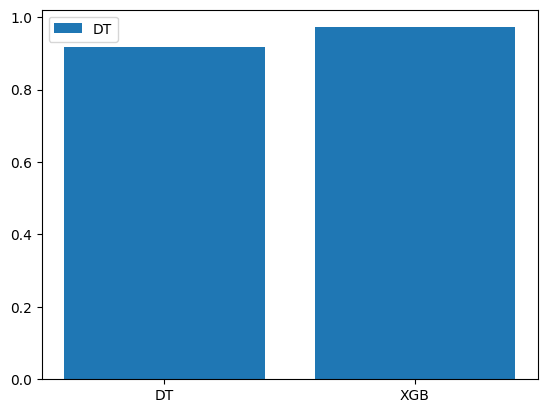

In [13]:
''' 코드를 작성해주세요 '''
import matplotlib.pyplot as plt

print(classification_report(y_test, DT_pred))
print(classification_report(y_test, XGB_pred))

models = ['DT', 'XGB']
scores = [DT, XGB]
plt.bar(models, scores)
plt.legend(['DT', 'XGB'])
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">